# Image registration with rotation, using Phase Correlation Method

How do we register two images, when one i a translated and rotated version of the other?
There are several methods using Image features, but what if there are no image features?

One can solve the case of a translated image using the Phase Correction Method, which perform FFT. In the FFT domain, a translation is encoded in the phase of the complex numbers.

In this quick algorithm, we assume a function for translation exists (there are various common implementations), and enhance it by adding a correction for the rotation.

In [ ]:
# this is a module to perform Phase Correlation Method
import image_registration

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import skimage.data
import skimage.filters
import skimage.transform

In [ ]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable


def imshow_with_colorbar(img, ax=None, title=None, **kwargs):
    if ax is None:
        _fig, ax = plt.subplots()
    im = ax.imshow(img, **kwargs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig = ax.get_figure()
    fig.colorbar(im, cax=cax, orientation="vertical")
    if title:
        ax.set_title(title)
    return ax, cax

# PCM

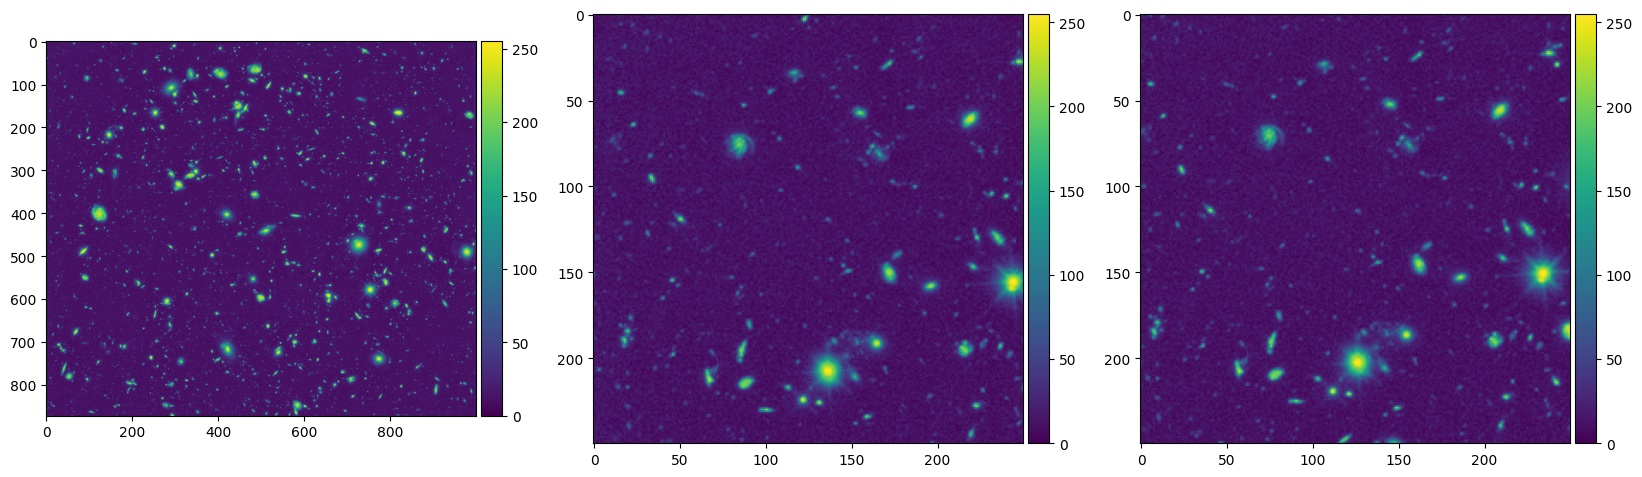

In [ ]:
image0 = skimage.data.hubble_deep_field().mean(axis=-1)

y0 = x0 = 10
N = 250
dy, dx = 27 // 5, 53 // 5

image1 = image0[y0 : y0 + N, x0 : x0 + N]
image2 = image0[y0 + dy : y0 + N + dy, x0 + dx : x0 + N + dx]

_fig, axs = plt.subplots(1, 3, figsize=(20, 10))
for image, ax in zip([image0, image1, image2], axs):
    imshow_with_colorbar(image, ax=ax)

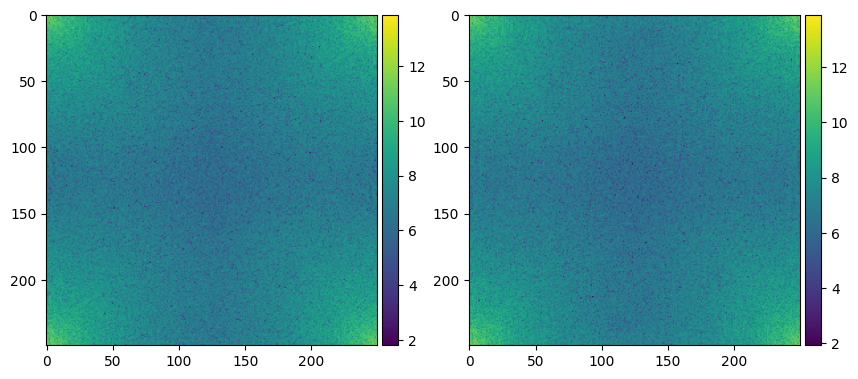

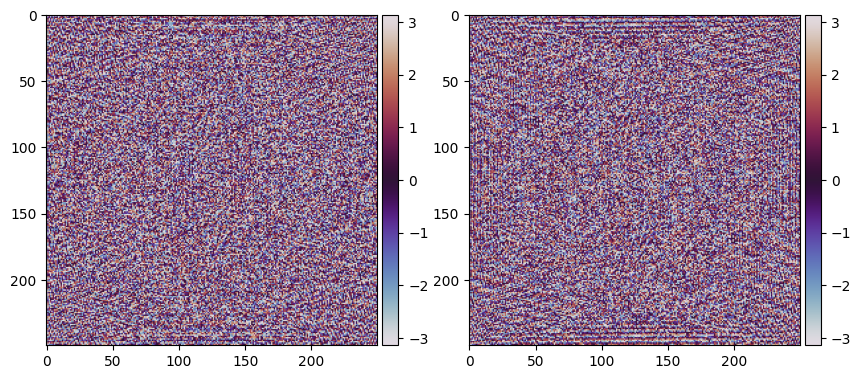

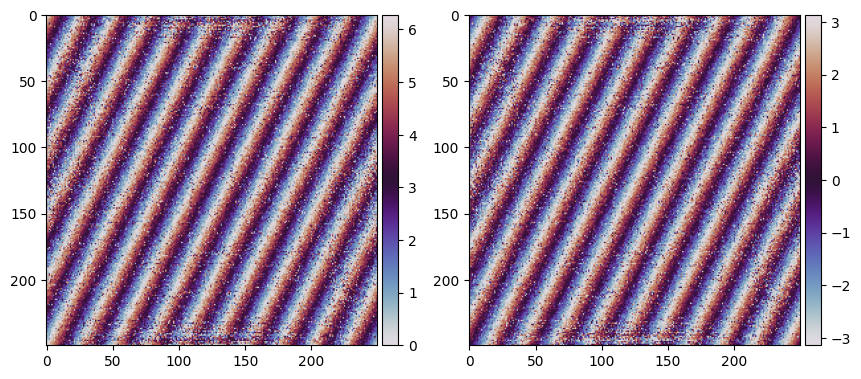

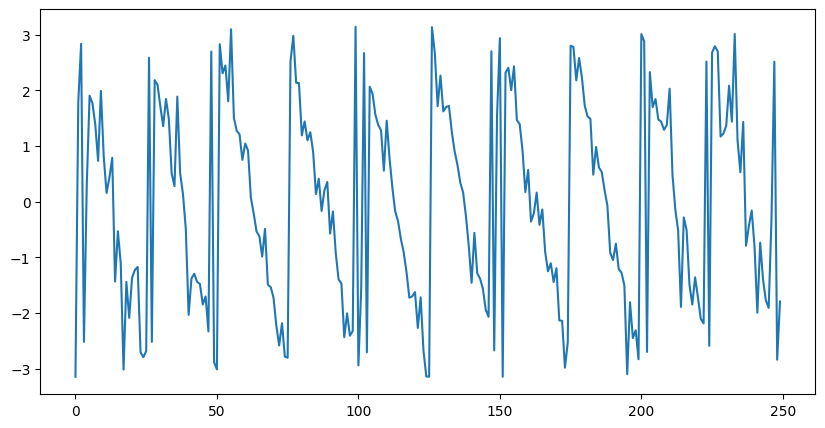

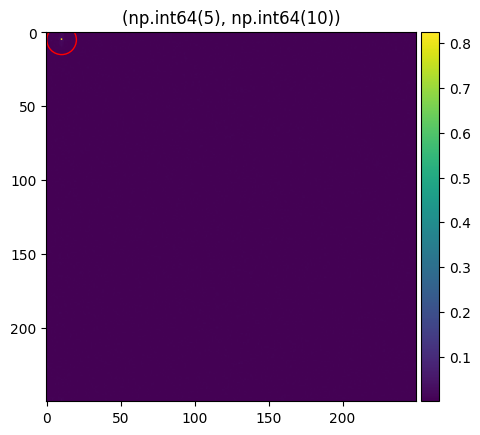

In [ ]:
fft1 = np.fft.fft2(image1)
fft2 = np.fft.fft2(image2)

_fig, axs = plt.subplots(1, 2, figsize=(10, 10))
for image, ax in zip([fft1, fft2], axs):
    imshow_with_colorbar(np.log(np.abs(image)), ax=ax)

_fig, axs = plt.subplots(1, 2, figsize=(10, 10))
for image, ax in zip([fft1, fft2], axs):
    imshow_with_colorbar(np.angle(image), ax=ax, cmap="twilight")


_fig, axs = plt.subplots(1, 2, figsize=(10, 10))

imshow_with_colorbar(
    (np.angle(fft1) - np.angle(fft2)) % (np.pi * 2), ax=axs[0], cmap="twilight"
)

ang = fft1 * fft2.conj() / np.abs(fft1 * fft2)
# imshow_with_colorbar(np.abs(ang))
imshow_with_colorbar(np.angle(ang), ax=axs[1], cmap="twilight")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.angle(ang)[N // 2])

image0b = np.fft.ifft2(ang)
a = np.unravel_index(image0b.argmax(), image0b.shape)
ax, _cax = imshow_with_colorbar(np.abs(image0b), title=a)
ax.add_patch(plt.Circle((dx, dy), 10, color="r", fill=False))
# imshow_with_colorbar(np.angle(image0b))

# simple case - a rectangle

## create the image

array([ 14., -12.])

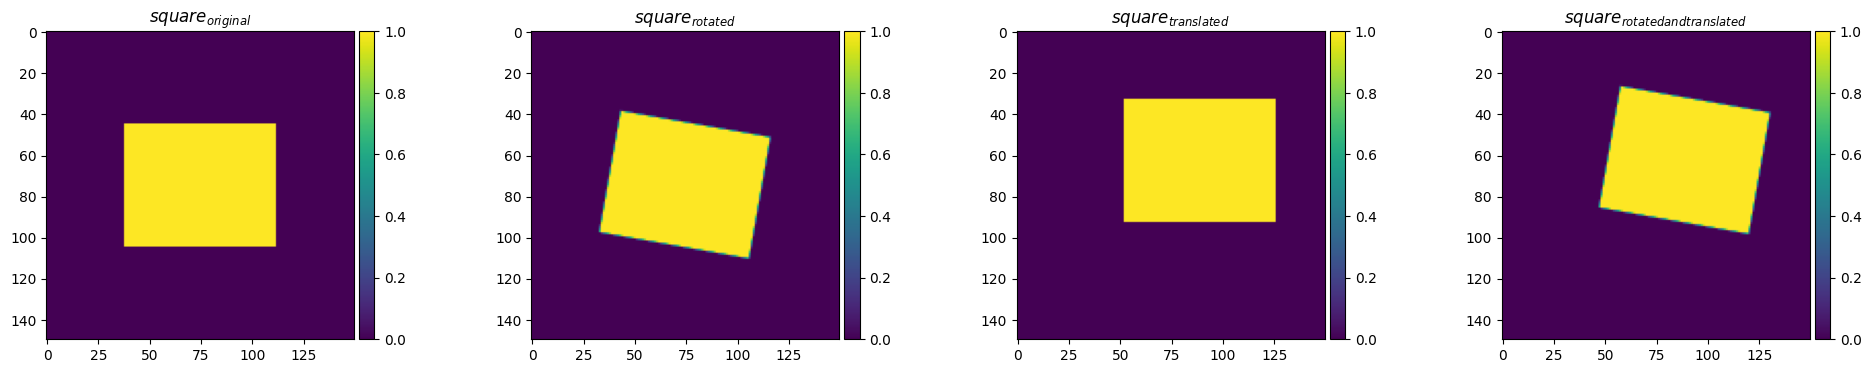

In [ ]:
images = {}

# the original image
N = 150
image1 = np.zeros(shape=(N, N))
h, w = N // 5, N // 4
image1[N // 2 - h : N // 2 + h, N // 2 - w : N // 2 + w] = 1
images["original"] = image1

# to demonstrate the method, we will show 3 image: translated, rotated, and both
theta_radians = np.deg2rad(10)
translation = (
    np.array(
        [
            [1 - np.cos(theta_radians), np.sin(theta_radians)],
            [-np.sin(theta_radians), 1 - np.cos(theta_radians)],
        ]
    )
    @ image1.shape
    // 2
)

display(translation)

# only rotated (around the center)
image2 = skimage.transform.warp(
    image1,
    inverse_map=skimage.transform.AffineTransform(
        rotation=theta_radians,
        translation=translation,  # to rotate around the center
    ).inverse,
    mode="reflect",
)
images["rotated"] = image2


# only translated
image3 = skimage.transform.warp(
    image1,
    inverse_map=skimage.transform.AffineTransform(translation=translation).inverse,
    mode="reflect",
)
images["translated"] = image3


# both rotated and translated
image4 = skimage.transform.warp(
    image2,
    inverse_map=skimage.transform.AffineTransform(translation=translation).inverse,
    mode="reflect",
)
images["rotated and translated"] = image4


# display the images
rows = 1
cols = math.ceil(4 / rows)
fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for (name, image), ax in zip(images.items(), axss.flatten()):
    imshow_with_colorbar(image, ax, title=f"$square_{{{name}}}$")

## in fft

we can see that after the Fourier, translations are irrelevant (i.e. they are encoded in the phase), only rotations remains

In [ ]:
def fft(image):
    image_fft_complex = np.fft.fft2(image)
    image_fft = np.abs(image_fft_complex)
    # image_fft[0, 0] = 0
    image_fft = np.roll(image_fft, image_fft.shape[0] // 2, axis=0)
    image_fft = np.roll(image_fft, image_fft.shape[1] // 2, axis=1)
    image_fft = np.log(image_fft)
    image_fft = np.clip(image_fft, 0, np.inf)
    return image_fft


def fft_phase(image):
    image_fft = np.angle(np.fft.fft2(image), deg=True)
    image_fft = np.roll(image_fft, image_fft.shape[0] // 2, axis=0)
    image_fft = np.roll(image_fft, image_fft.shape[1] // 2, axis=1)
    # image_fft = np.log(image_fft)
    # image_fft = np.clip(image_fft, 0, np.inf)
    return image_fft

/tmp/ipykernel_67111/3430890014.py:7: RuntimeWarning: divide by zero encountered in log
  image_fft = np.log(image_fft)
/tmp/ipykernel_67111/162104077.py:14: RuntimeWarning: invalid value encountered in divide
  imshow_with_colorbar(np.angle((fft1*fft3.conj())/np.abs(fft1*fft3.conj())), cmap="twilight")


(<Axes: >, <Axes: >)

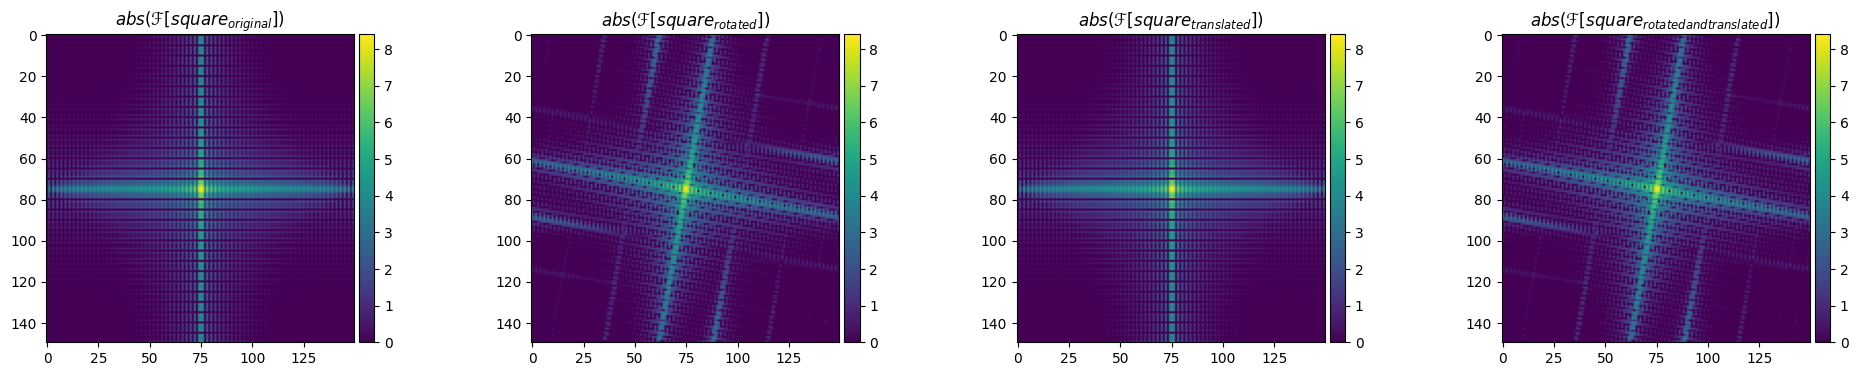

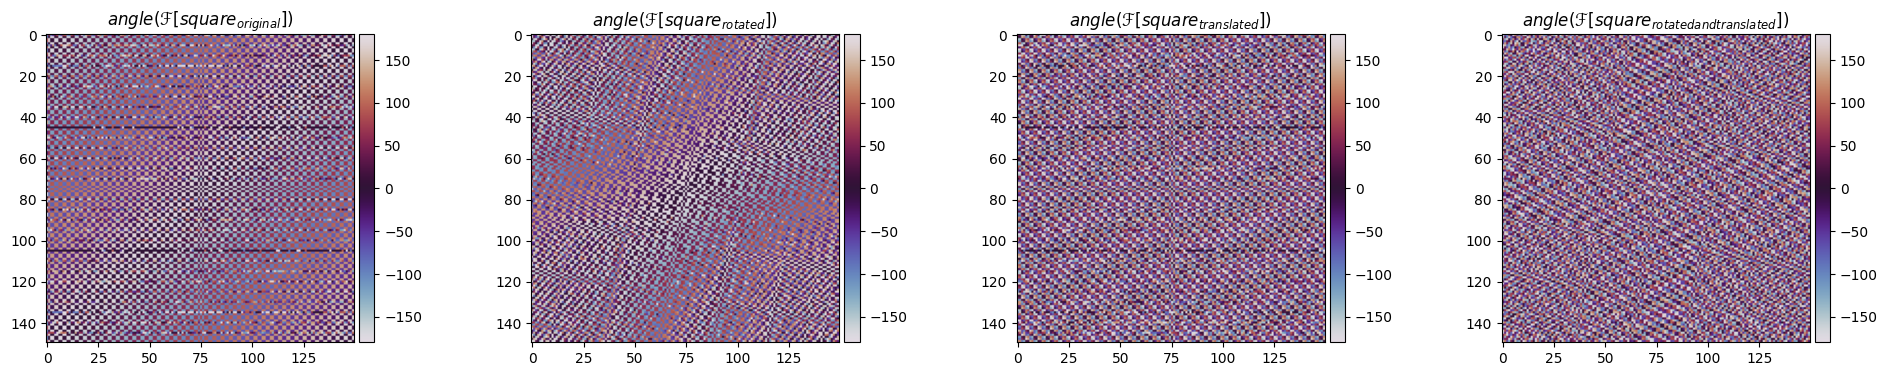

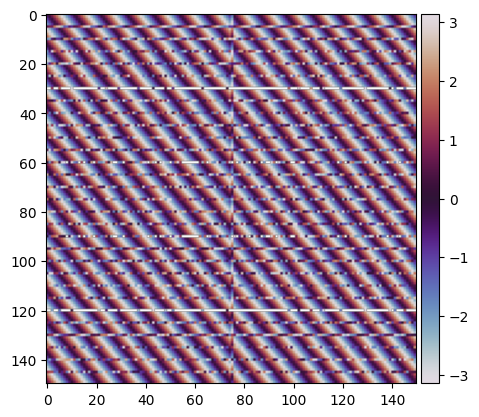

In [ ]:
rows = 1
cols = math.ceil(4 / rows)
fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))

for (name, image), ax in zip(images.items(), axss.flatten()):
    imshow_with_colorbar(fft(image), ax, title=f"$abs(ℱ[square_{{{name}}}])$")

fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for (name, image), ax in zip(images.items(), axss.flatten()):
    imshow_with_colorbar(
        fft_phase(image), ax, title=f"$angle(ℱ[square_{{{name}}}])$", cmap="twilight"
    )

fft1 = np.fft.fft2(image1)
fft3 = np.fft.fft2(image3)
imshow_with_colorbar(
    np.angle((fft1 * fft3.conj()) / np.abs(fft1 * fft3.conj())), cmap="twilight"
)

## in polar coordinates

so, if we transform the fft image to polar coordinates, translations will be irrelevant and rotations will be translations.

notice how the images on the side are translated downward by the degree amount.

/tmp/ipykernel_67111/3430890014.py:7: RuntimeWarning: divide by zero encountered in log
  image_fft = np.log(image_fft)


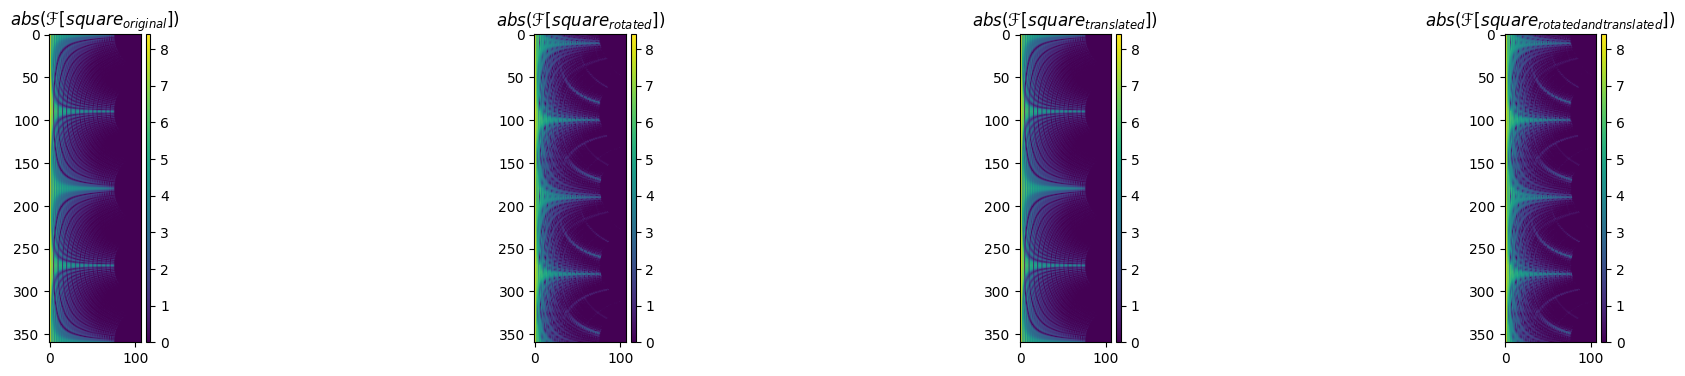

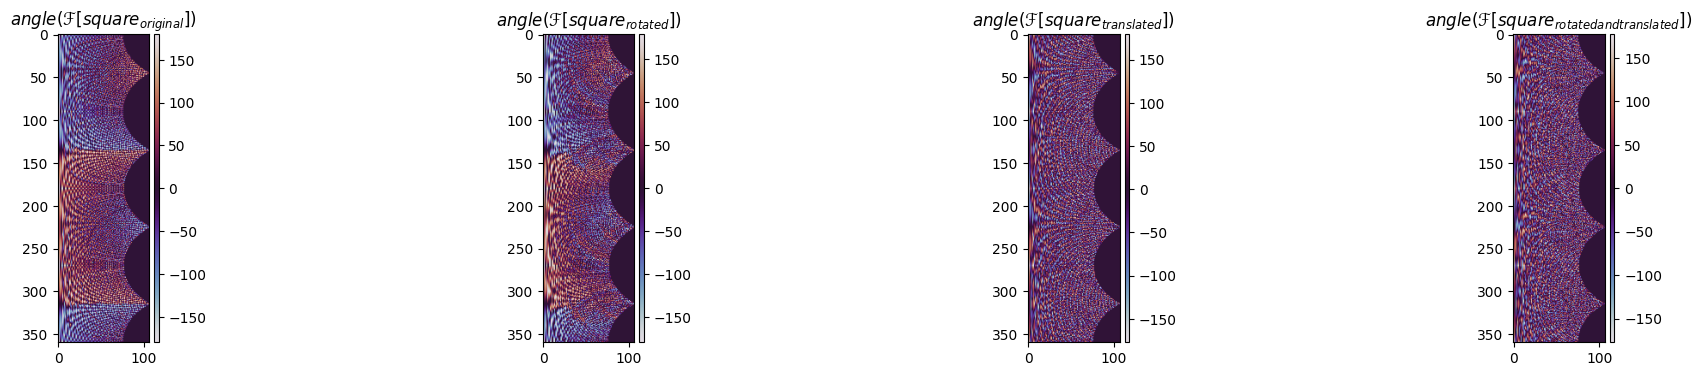

In [ ]:
def to_polar(image):
    return skimage.transform.warp_polar(
        image, center=np.array(image.shape) // 2, scaling="linear"
    )


rows = 1
cols = math.ceil(4 / rows)
fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for (name, image), ax in zip(images.items(), axss.flatten()):
    imshow_with_colorbar(to_polar(fft(image)), ax, title=f"$abs(ℱ[square_{{{name}}}])$")

fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for (name, image), ax in zip(images.items(), axss.flatten()):
    imshow_with_colorbar(
        to_polar(fft_phase(image)),
        ax,
        title=f"$angle(ℱ[square_{{{name}}}])$",
        cmap="twilight",
    )

(<Axes: >, <Axes: >)

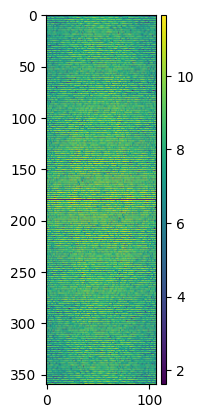

In [ ]:
imshow_with_colorbar(fft(to_polar(fft_phase(image4))))

## unrotating

we use the image registration function to unrotate.
This image registration is actually working in the FFT of the input image (so, in our case FFT of polar of FFT), and uses the phase information to determine the translation.

/tmp/ipykernel_67111/3430890014.py:7: RuntimeWarning: divide by zero encountered in log
  image_fft = np.log(image_fft)


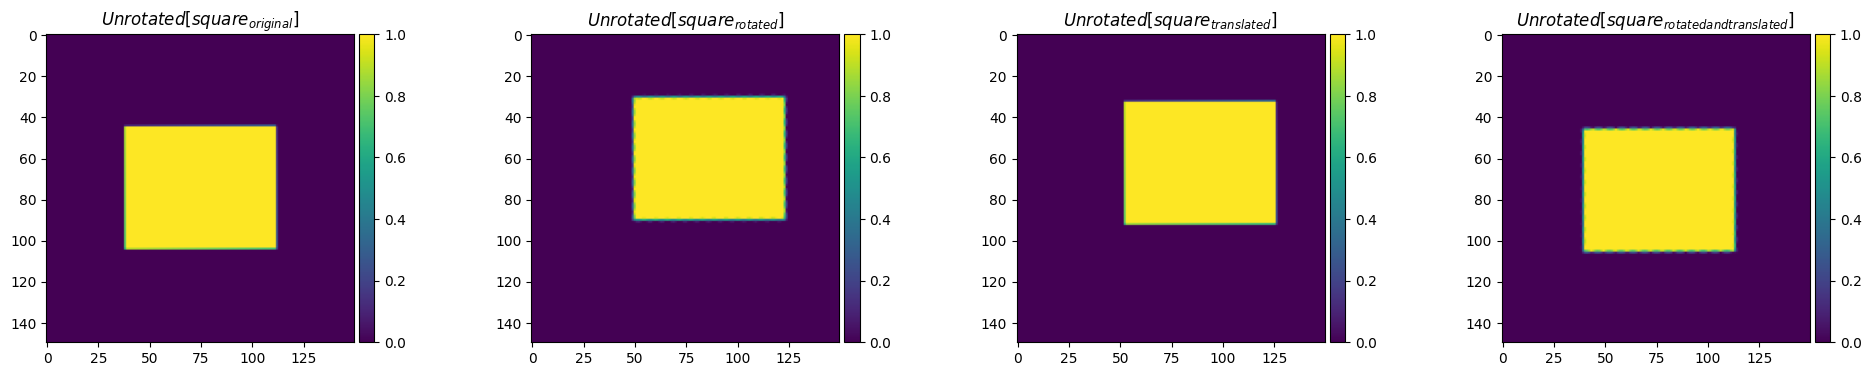

In [ ]:
def unrotate_image(src, dst):
    src_fft = to_polar(fft(src))
    dst_fft = to_polar(fft(dst))
    dr, dq, var_r, var_q = image_registration.chi2_shift(
        src_fft, dst_fft, boundary="wrap"
    )
    dr_max = src_fft.shape[1]
    dr = (dr + dr_max // 2) % dr_max - dr_max // 2
    assert abs(dr) < 0.5
    dq_deg = 360 * dq / src_fft.shape[0]
    dq_deg = (dq_deg + 180) % 360 - 180

    return skimage.transform.warp(
        src,
        inverse_map=skimage.transform.AffineTransform(
            rotation=np.deg2rad(dq_deg)
        ).inverse,
        mode="wrap",
    )


unrotated_images = {
    name: unrotate_image(image, image1) for name, image in images.items()
}

rows = 1
cols = math.ceil(4 / rows)
fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for (name, image), ax in zip(unrotated_images.items(), axss.flatten()):
    imshow_with_colorbar(image, ax, title=f"$Unrotated[square_{{{name}}}]$")

we use the same function to untranslate

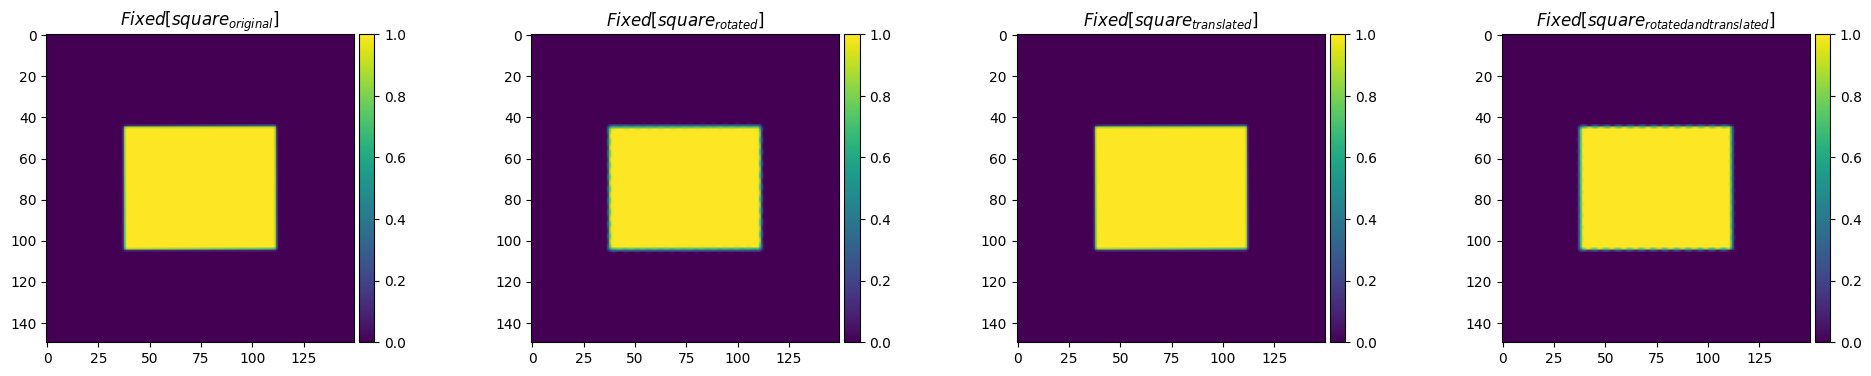

In [ ]:
def untranslate_image(src, dst):
    dy, dx, var_y, var_x = image_registration.chi2_shift(src, dst, boundary="wrap")

    return skimage.transform.warp(
        src,
        inverse_map=skimage.transform.AffineTransform(translation=(dy, dx)).inverse,
        mode="wrap",
    )


fixed_images = {
    name: untranslate_image(image, image1) for name, image in unrotated_images.items()
}

rows = 1
cols = math.ceil(4 / rows)
fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for (name, image), ax in zip(fixed_images.items(), axss.flatten()):
    imshow_with_colorbar(image, ax, title=f"$Fixed[square_{{{name}}}]$")

# more complex image

This demonstrate the use of the method on an image that lacks features.

## create an image

In [ ]:
N = 150
upscale = 10
np.random.seed(0)

In [ ]:
image_seed = np.random.uniform(size=(N, N))

(<Axes: >, <Axes: >)

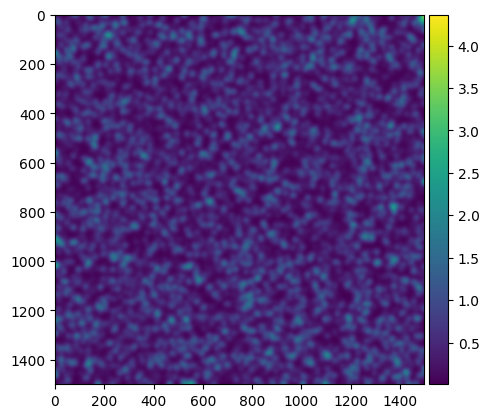

In [ ]:
image = image_seed
image = image.repeat(upscale, axis=0).repeat(upscale, axis=1)
image_sum = image.sum()
image = image**10
image = skimage.filters.gaussian(image, upscale)
# image = image - np.quantile(image, 0.99)
image = np.clip(image, 0, np.inf)

image = image / image.sum() * image_sum

imshow_with_colorbar(image)

we take this upscaled generated image and sample 2 images from it, with slight rotation/translation between them

In [ ]:
margin = N // 10
image1 = image[::upscale, ::upscale][margin:-margin, margin:-margin]

dx, dy = 13, 17
theta_radians = np.deg2rad(3)
tform = skimage.transform.AffineTransform(
    scale=1, rotation=theta_radians, shear=0, translation=(dx * upscale, dy * upscale)
)

image2 = skimage.transform.warp(image, inverse_map=tform.inverse, mode="reflect")
image2 = image2[::upscale, ::upscale][margin:-margin, margin:-margin]

# add some noise
for _i in range(7):
    x1, y1 = np.random.uniform(size=2)
    x2 = min(1, x1 + 0.1)
    y2 = min(1, y1 + 0.1)
    image2[
        int(image2.shape[0] * x1) : int(image2.shape[0] * x2),
        int(image2.shape[1] * y1) : int(image2.shape[1] * y2),
    ] = 0

## run registration

we use the same functions from before to fix the 2nd image to the first

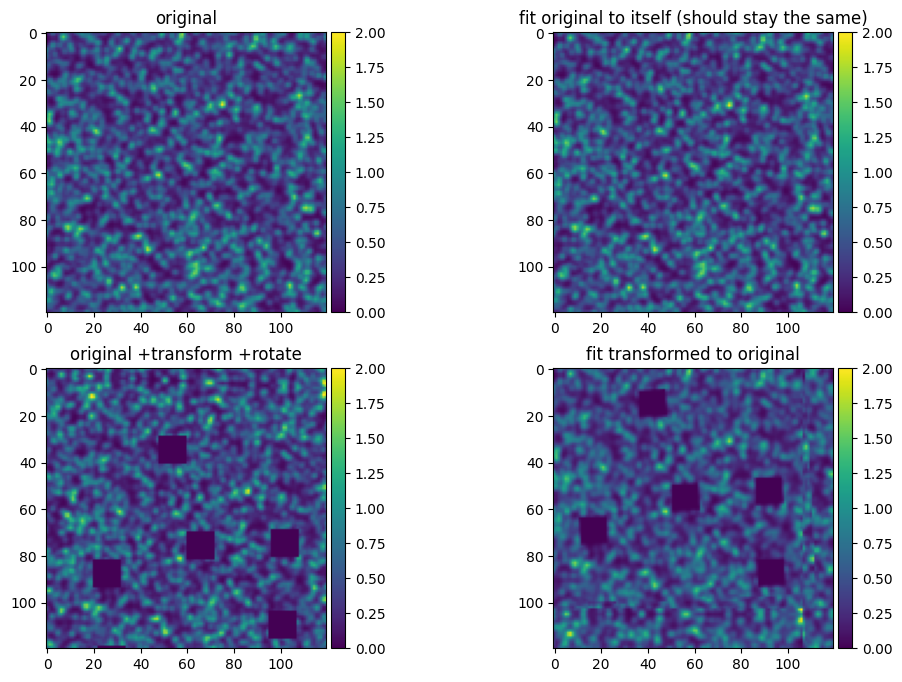

In [ ]:
images = [image1, image2]
rows = len(images)
cols = 2
fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for image_, axs in zip(images, axss):
    imshow_with_colorbar(image_, axs[0], vmin=0, vmax=2)
    imshow_with_colorbar(
        untranslate_image(unrotate_image(image_, image1), image1),
        axs[1],
        vmin=0,
        vmax=2,
    )
axss[0][0].set_title("original")
axss[1][0].set_title("original +transform +rotate")
axss[0][1].set_title("fit original to itself (should stay the same)")
axss[1][1].set_title("fit transformed to original");

here we compare 2 images using the R and G channels of an RGB image.

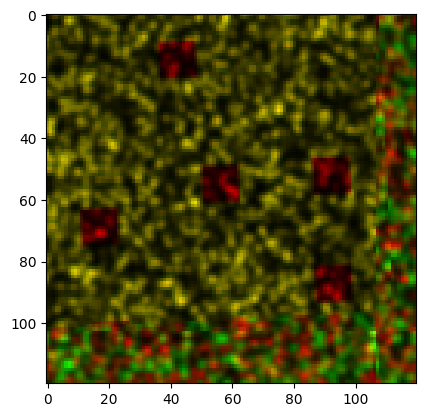

In [ ]:
image2_fixed = untranslate_image(unrotate_image(image2, image1), image1)
plt.imshow(
    np.stack(
        [
            image1 / image1.max(),
            image2_fixed / image2_fixed.max(),
            np.zeros_like(image2),
        ],
        axis=-1,
    )
)

## Try PCM

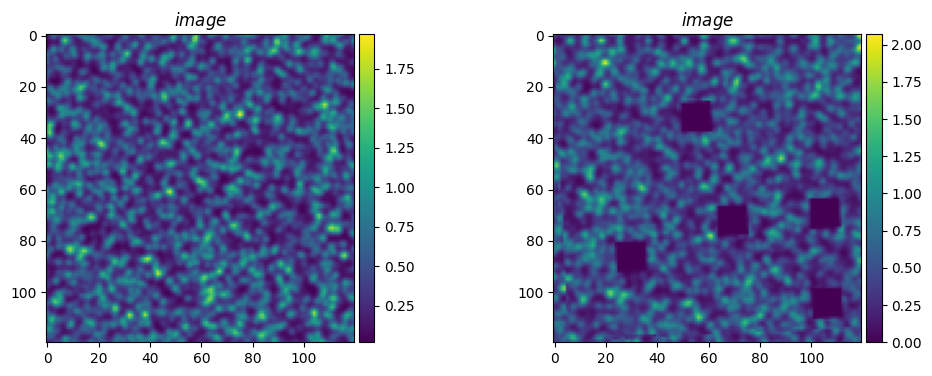

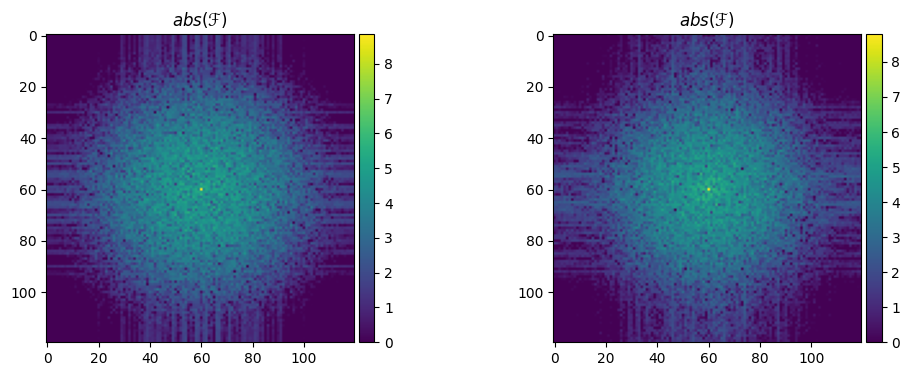

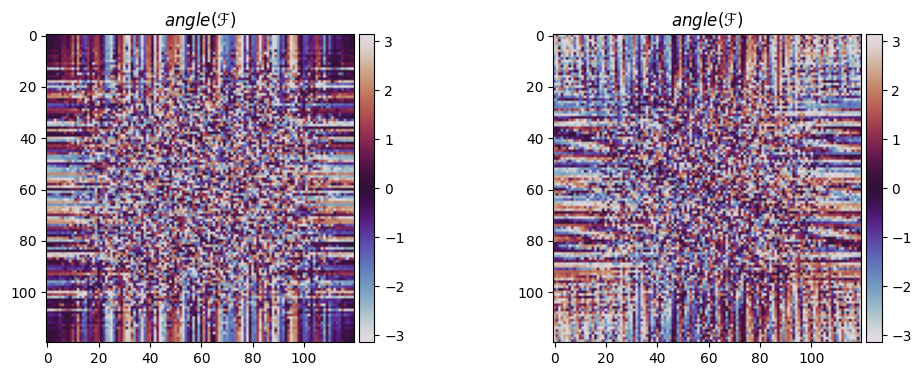

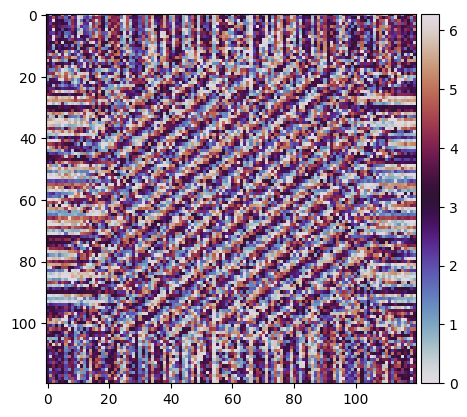

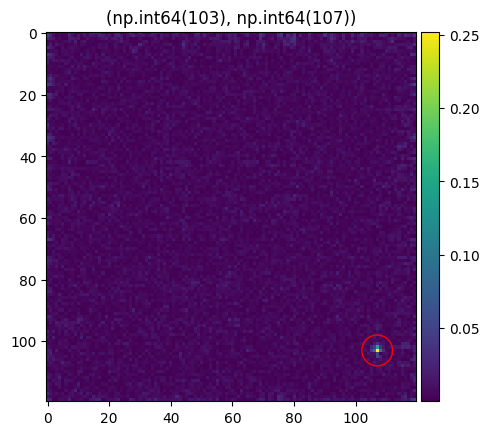

In [ ]:
rows = 1
cols = math.ceil(2 / rows)

images = [image1, unrotate_image(image2, image1)]

fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for image, ax in zip(images, axss.flatten()):
    imshow_with_colorbar(image, ax, title="$image$")

fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
for image, ax in zip(images, axss.flatten()):
    imshow_with_colorbar(fft(image), ax, title="$abs(ℱ)$")

fig, axss = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
a1 = fft_phase(images[0]) / 180 * np.pi
a2 = fft_phase(images[1]) / 180 * np.pi
for image, ax in zip([a1, a2], axss.flatten()):
    imshow_with_colorbar(image, ax, title="$angle(ℱ)$", cmap="twilight")

imshow_with_colorbar((a2 - a1) % (2 * np.pi), cmap="twilight")


fft1 = np.fft.fft2(images[0])
fft2 = np.fft.fft2(images[1])

ang = fft1 * fft2.conj() / np.abs(fft1 * fft2)
image0b = np.fft.ifft2(ang)

a = np.unravel_index(image0b.argmax(), image0b.shape)
ax, _cax = imshow_with_colorbar(np.abs(image0b), title=a)
ax.add_patch(plt.Circle((120 - 13, 120 - 17), 5, color="r", fill=False))
# imshow_with_colorbar(np.angle(image0b))